# RuthST Evaluation Plotting Notebook

This notebook reads `runtime_summary.csv` and `collectl_summary.csv` from the RuthST evaluation folders and generates paper-style figures. It keeps CPU and memory in separate figures because they use different units and represent different bottlenecks.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Global style, close to main-jliu.ipynb
# =========================
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.figsize": (8, 5.5),
    "lines.linewidth": 3.0,
    "lines.markersize": 9,
    "axes.linewidth": 1.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

BLUE = "#3d77aa"
GREEN = "#3a923a"
ORANGE = "#ff9f1c"
RED = "#d62728"
GRAY = "#555555"


def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, format="pdf", bbox_inches="tight")
    print(f"[Saved] {path}")


def clean_axes(ax, grid=False):
    ax.grid(grid, axis="y", alpha=0.25, color="black")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=16)
    return ax


## Input Paths

Update these paths if your result folders use different names. The notebook includes the Ostrava worker sweep folder (`ostrava_worker_sweep_2`) and the CBR folders.


In [2]:
# Runtime summaries
OSTRAVA_RUNTIME = Path("results/ostrava_worker_sweep_2/runtime_summary.csv")
CBR_WORKER_RUNTIME = Path("results/cbr_worker_sweep/runtime_summary.csv")
CBR_WORKLOAD_RUNTIME = Path("results/cbr_workload_scaling/runtime_summary.csv")

# Collectl summaries
OSTRAVA_COLLECTL = Path("results/ostrava_worker_sweep_2/collectl_summary.csv")
CBR_WORKER_COLLECTL = Path("results/cbr_worker_sweep/collectl_summary.csv")
CBR_WORKLOAD_COLLECTL = Path("results/cbr_workload_scaling/collectl_summary.csv")

# Optional manual chunk-size sensitivity table, from CBR 2pc experiments
chunk_df = pd.DataFrame({
    "chunk_size_m": [2, 4, 8, 12, 16, 32],
    "tasks": [71, 36, 18, 12, 9, 5],
    "conversion_sec": [1366, 763, 470, 395, 372, 381],
    "collect_sec": [564, 305, 197, 194, 205, 263],
    "merge_sec": [781, 440, 257, 185, 150, 102],
})


In [3]:
def read_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        print(f"[Missing] {path}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f"[Loaded] {path}: {df.shape}")
    return df

ostrava_rt = read_csv_if_exists(OSTRAVA_RUNTIME)
cbr_worker_rt = read_csv_if_exists(CBR_WORKER_RUNTIME)
cbr_workload_rt = read_csv_if_exists(CBR_WORKLOAD_RUNTIME)

ostrava_col = read_csv_if_exists(OSTRAVA_COLLECTL)
cbr_worker_col = read_csv_if_exists(CBR_WORKER_COLLECTL)
cbr_workload_col = read_csv_if_exists(CBR_WORKLOAD_COLLECTL)


[Loaded] results/ostrava_worker_sweep_2/runtime_summary.csv: (16, 12)
[Loaded] results/cbr_worker_sweep/runtime_summary.csv: (6, 13)
[Loaded] results/cbr_workload_scaling/runtime_summary.csv: (5, 13)
[Loaded] results/ostrava_worker_sweep_2/collectl_summary.csv: (15, 12)
[Loaded] results/cbr_worker_sweep/collectl_summary.csv: (6, 12)
[Loaded] results/cbr_workload_scaling/collectl_summary.csv: (5, 12)


## Helper Functions

The runtime summaries already contain `workers`, `portion`, `conversion_sec`, and `wall_sec`. The collectl filenames encode the same experiment setting, so the helper below extracts `city`, `portion`, `workers`, and `chunk_size` from the collectl file names.


In [4]:
import re


def enrich_from_file_name(df):
    if df.empty or "file" not in df.columns:
        return df
    out = df.copy()
    out["city"] = out["file"].str.extract(r"^(ostrava|cbr)_", expand=False)
    out["portion"] = out["file"].str.extract(r"_(\d+pc)_", expand=False)
    out["workers"] = out["file"].str.extract(r"_w(\d+)", expand=False).astype(float)
    out["chunk_size"] = out["file"].str.extract(r"_chunk(\d+)", expand=False).astype(float)
    out["repeat"] = out["file"].str.extract(r"_r(\d+)", expand=False).fillna(1).astype(int)
    return out


def summarize_by_workers(df, value_cols):
    if df.empty:
        return df
    cols = [c for c in value_cols if c in df.columns]
    return df.groupby("workers", as_index=False)[cols].mean().sort_values("workers")


def add_speedup(df, time_col="conversion_sec"):
    out = df.copy().sort_values("workers")
    base = out.loc[out["workers"] == out["workers"].min(), time_col].iloc[0]
    out["speedup"] = base / out[time_col]
    out["efficiency"] = out["speedup"] / out["workers"]
    return out

ostrava_col = enrich_from_file_name(ostrava_col)
cbr_worker_col = enrich_from_file_name(cbr_worker_col)
cbr_workload_col = enrich_from_file_name(cbr_workload_col)


## Figure 1: Ostrava Worker Scalability

This figure uses `results/ostrava_worker_sweep_2/runtime_summary.csv`.


,workers,conversion_sec,wall_sec,rss_gb
0,1,113.270000,117.830000,2.817188
1,2,77.556667,82.353333,2.849286
2,4,56.653333,61.500000,2.859590
3,8,47.596667,52.493333,2.854031
4,16,50.403333,55.423333,2.870125
5,32,44.050000,48.370000,2.945999


/tmp/ipykernel_170199/3151109461.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis="y", alpha=0.25, color="black")


[Saved] figures/ostrava_worker_scaling_time_bar.pdf


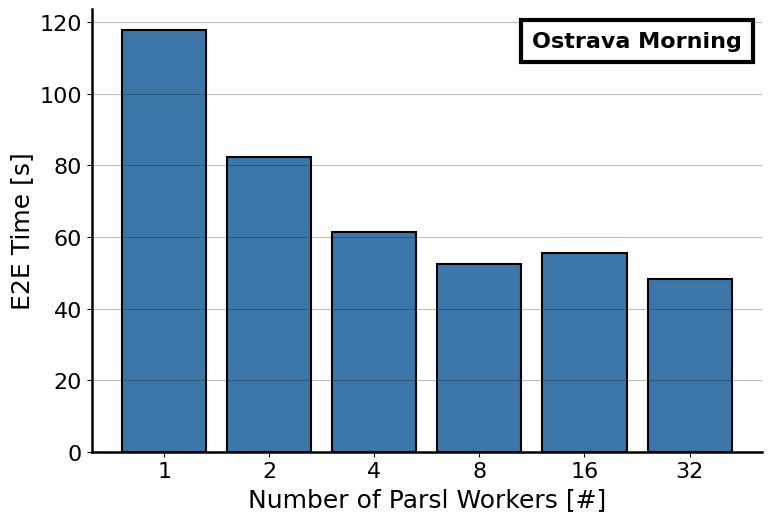

In [5]:
if not ostrava_rt.empty:
    ostrava_worker = summarize_by_workers(
        ostrava_rt,
        ["conversion_sec", "wall_sec", "rss_gb"]
    )
    display(ostrava_worker)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    bars = ax.bar(
        ostrava_worker["workers"].astype(str),
        ostrava_worker["wall_sec"],
        color=BLUE,
        edgecolor="black",
        linewidth=1.5
    )

    ax.set_xlabel("Number of Parsl Workers [#]")
    ax.set_ylabel("E2E Time [s]")
    ax.text(
    0.97, 0.95,
    "Ostrava Morning",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="square,pad=0.5",
        facecolor="white",
        edgecolor="black",
        linewidth=3
        )
    )

    clean_axes(ax, grid=False)
    plt.tight_layout()
    savefig("ostrava_worker_scaling_time_bar.pdf")
    plt.show()

## Figure 2: CBR Worker Scalability

This figure uses `results/cbr_worker_sweep/runtime_summary.csv`.


,workers,conversion_sec,wall_sec,rss_gb,cpu_percent
0,1,753.34,800.51,22.902561,43.0
1,2,524.30,571.89,22.902576,59.0
2,4,415.94,463.33,22.901554,73.0
3,8,373.88,421.31,22.927593,82.0
4,16,377.75,425.05,22.928837,82.0
5,32,373.12,420.06,22.929218,82.0


/tmp/ipykernel_170199/3151109461.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis="y", alpha=0.25, color="black")


[Saved] figures/cbr_worker_scaling_time_bar.pdf


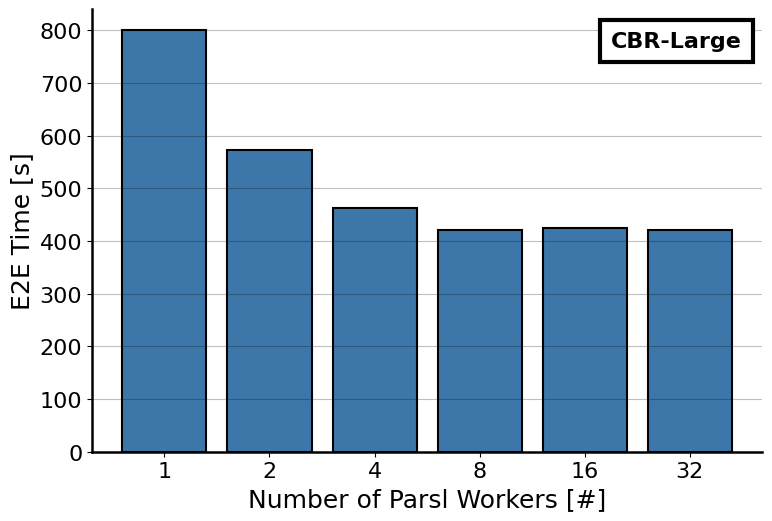

In [6]:
if not cbr_worker_rt.empty:
    cbr_worker = summarize_by_workers(
        cbr_worker_rt,
        ["conversion_sec", "wall_sec", "rss_gb", "cpu_percent"]
    )
    display(cbr_worker)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    bars = ax.bar(
        cbr_worker["workers"].astype(str),
        cbr_worker["wall_sec"],
        color=BLUE,
        edgecolor="black",
        linewidth=1.5
    )
    ax.text(
    0.97, 0.95,
    "CBR-Large",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="square,pad=0.5",
        facecolor="white",
        edgecolor="black",
        linewidth=3
        )
    )

    ax.set_xlabel("Number of Parsl Workers [#]")
    ax.set_ylabel("E2E Time [s]")

    clean_axes(ax, grid=False)
    plt.tight_layout()
    savefig("cbr_worker_scaling_time_bar.pdf")
    plt.show()


## Figure 3: CBR Workload Scaling

This figure uses `results/cbr_workload_scaling/runtime_summary.csv`. It plots wall-clock time and conversion time against workload size labels.


,dataset,data_points,conversion_sec,wall_sec,rss_gb
0,Ostrava Morning,1.18M,46.84,51.67,2.855576
1,CBR-Small,CBR-Small,60.68,108.34,4.535187
2,CBR-Medium,CBR-Medium,83.11,129.15,4.947315
3,CBR-Large,CBR-Large,370.46,417.54,22.929825
4,CBR-XLarge,CBR-XLarge,765.50,812.63,30.287872


/tmp/ipykernel_170199/3151109461.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis="y", alpha=0.25, color="black")


[Saved] figures/workload_scaling_wall_time_bar.pdf


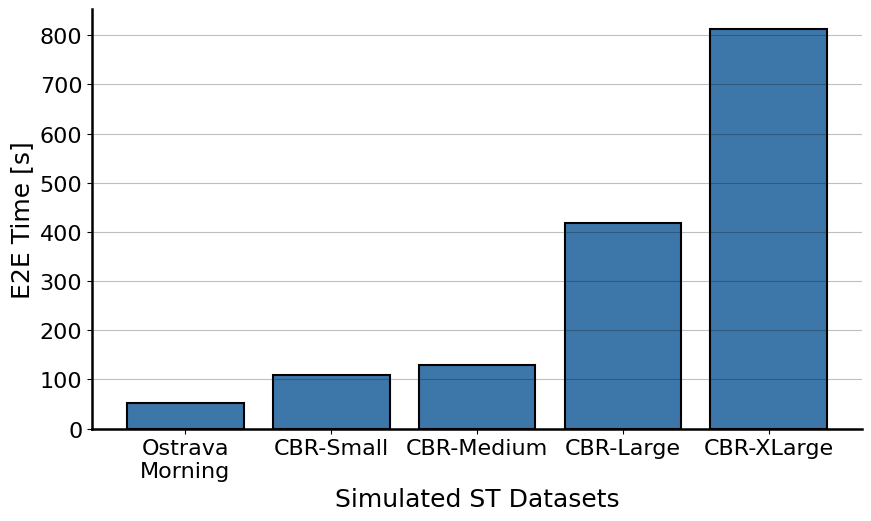

In [7]:
# ============================================================
# Workload Scaling: Ostrava + CBR
# ============================================================

rows = []

# Ostrava baseline: use best observed worker setting, usually 8 workers.
if not ostrava_rt.empty:
    tmp = ostrava_rt[ostrava_rt["workers"] == 8].copy()
    if tmp.empty:
        tmp = ostrava_rt.copy()
    r = tmp.sort_values("conversion_sec").iloc[0]
    rows.append({
        "label": "Ostrava\nMorning",
        "dataset": "Ostrava Morning",
        "data_points": "1.18M",
        "wall_sec": float(r["wall_sec"]),
        "conversion_sec": float(r["conversion_sec"]),
        "rss_gb": float(r["rss_gb"]) if "rss_gb" in r and pd.notna(r["rss_gb"]) else np.nan,
    })

# CBR rows: manually define order and labels.
cbr_specs = [
    ("7pc", "CBR-Small"),
    ("6pc", "CBR-Medium"),
    ("2pc", "CBR-Large"),
    ("1pc", "CBR-XLarge"),
]

if not cbr_workload_rt.empty:
    for portion, label in cbr_specs:
        tmp = cbr_workload_rt[cbr_workload_rt["portion"].astype(str) == portion].copy()
        if tmp.empty:
            continue
        r = tmp.iloc[0]
        rows.append({
            "label": label,
            "dataset": label.replace("\n", " "),
            "data_points": label.split("\n")[-1],
            "wall_sec": float(r["wall_sec"]),
            "conversion_sec": float(r["conversion_sec"]) if pd.notna(r["conversion_sec"]) else np.nan,
            "rss_gb": float(r["rss_gb"]) if "rss_gb" in r and pd.notna(r["rss_gb"]) else np.nan,
        })

workload_df = pd.DataFrame(rows)
display(workload_df[["dataset", "data_points", "conversion_sec", "wall_sec", "rss_gb"]])

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    workload_df["label"],
    workload_df["wall_sec"],
    color=BLUE,
    edgecolor="black",
    linewidth=1.5
)

ax.set_xlabel("Simulated ST Datasets")
ax.set_ylabel("E2E Time [s]")

ymax = workload_df["wall_sec"].max()

clean_axes(ax, grid=False)
plt.tight_layout()
savefig("workload_scaling_wall_time_bar.pdf")
plt.show()


## Figure 4: CBR Chunk-Size Sensitivity

This uses the manually entered CBR 2pc chunk-size results.


/tmp/ipykernel_125843/3151109461.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis="y", alpha=0.25, color="black")


[Saved] figures/cbr_chunk_size_sensitivity_bar.pdf


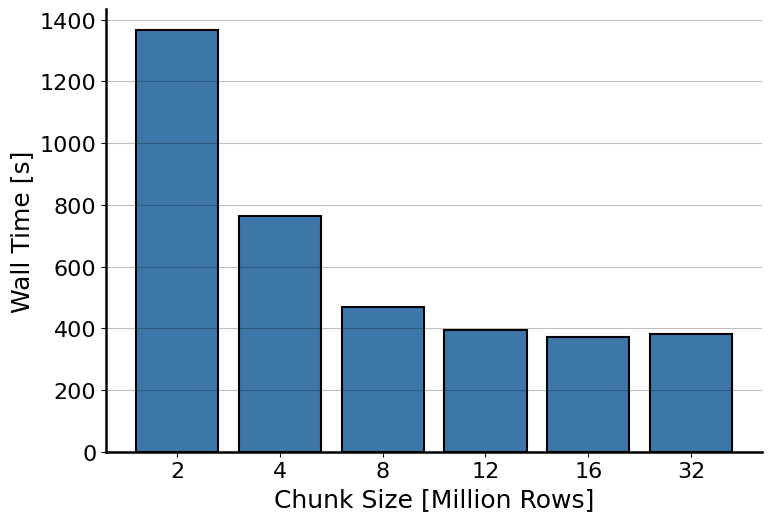

/tmp/ipykernel_125843/3151109461.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis="y", alpha=0.25, color="black")


[Saved] figures/cbr_chunk_aggregation_breakdown_bar.pdf


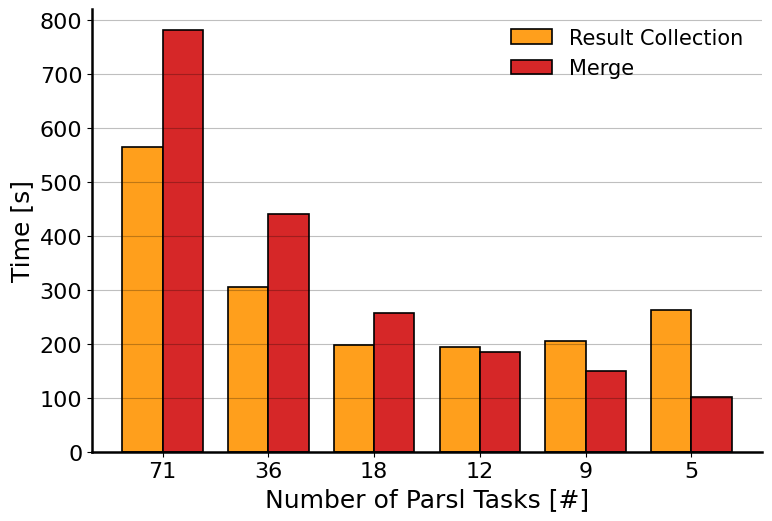

In [33]:
fig, ax = plt.subplots(figsize=(8, 5.5))

ax.bar(
    chunk_df["chunk_size_m"].astype(str),
    chunk_df["conversion_sec"],
    color=BLUE,
    edgecolor="black",
    linewidth=1.5
)

ax.set_xlabel("Chunk Size [Million Rows]")
ax.set_ylabel("Wall Time [s]")

clean_axes(ax, grid=False)
plt.tight_layout()
savefig("cbr_chunk_size_sensitivity_bar.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5.5))

x = np.arange(len(chunk_df))
width = 0.38

ax.bar(
    x - width/2,
    chunk_df["collect_sec"],
    width,
    label="Result Collection",
    color=ORANGE,
    edgecolor="black",
    linewidth=1.2
)

ax.bar(
    x + width/2,
    chunk_df["merge_sec"],
    width,
    label="Merge",
    color=RED,
    edgecolor="black",
    linewidth=1.2
)

ax.set_xlabel("Number of Parsl Tasks [#]")
ax.set_ylabel("Time [s]")

ax.set_xticks(x)
ax.set_xticklabels(chunk_df["tasks"])

ax.legend(frameon=False)

clean_axes(ax, grid=False)
plt.tight_layout()
savefig("cbr_chunk_aggregation_breakdown_bar.pdf")
plt.show()


## Figure 5: CPU Utilization

CPU utilization is plotted as a separate figure. Do not combine it with memory usage because the units and interpretation are different.


,workers,avg_cpu_busy_pct,max_cpu_busy_pct,avg_cpu_iowait_pct
0,1.0,7.488032,24.608641,0.006816
1,2.0,10.734876,30.075188,0.008244
2,4.0,13.912226,40.801001,0.015364
3,8.0,16.538089,61.114590,0.013802
4,16.0,16.671271,92.230576,0.006957
5,32.0,16.798767,73.720350,0.008967


/tmp/ipykernel_125843/3151109461.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis="y", alpha=0.25, color="black")


[Saved] figures/cbr_worker_cpu_utilization_bar.pdf


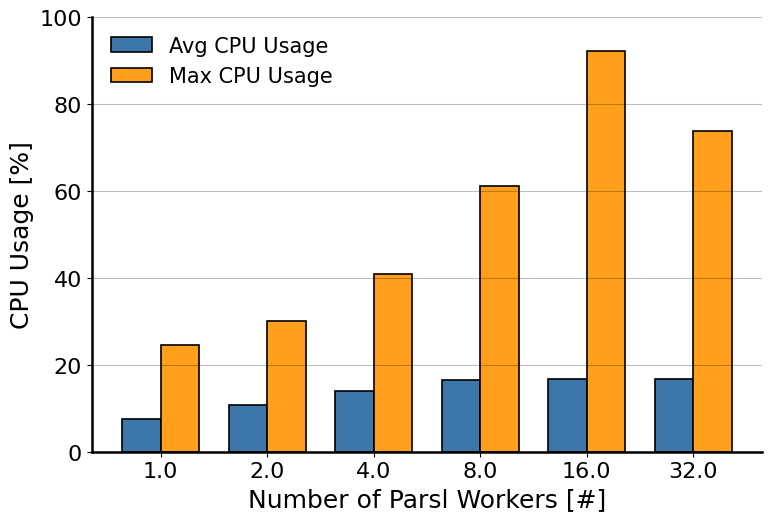

/tmp/ipykernel_125843/3151109461.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis="y", alpha=0.25, color="black")


[Saved] figures/cbr_workload_cpu_utilization.pdf


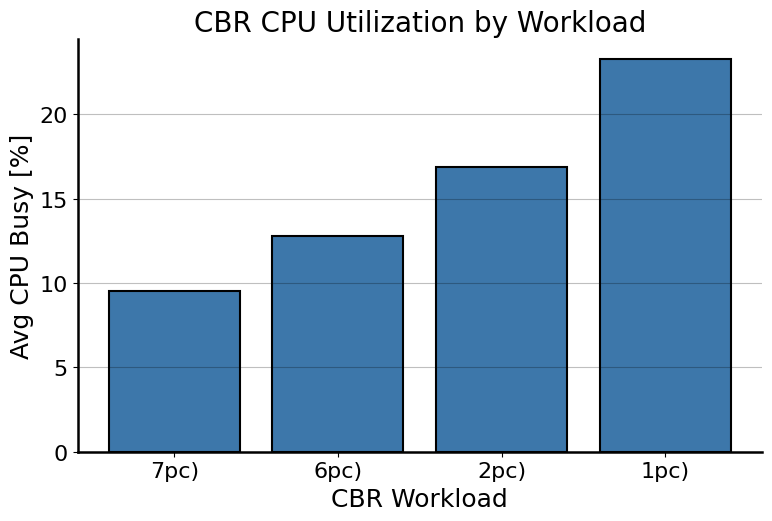

In [29]:
# ============================================================
# Global Plot Settings
# ============================================================

portion_order = ["7pc", "6pc", "2pc", "1pc"]

size_labels = {
    "7pc": "21M",
    "6pc": "52M",
    "2pc": "141M",
    "1pc": "446M",
}

if not cbr_worker_col.empty:
    cpu_df = summarize_by_workers(
        cbr_worker_col,
        ["avg_cpu_busy_pct", "max_cpu_busy_pct", "avg_cpu_iowait_pct"]
    )
    display(cpu_df)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    x = np.arange(len(cpu_df))
    width = 0.36

    ax.bar(
        x - width/2,
        cpu_df["avg_cpu_busy_pct"],
        width,
        label="Avg CPU Usage",
        color=BLUE,
        edgecolor="black",
        linewidth=1.2
    )

    ax.bar(
        x + width/2,
        cpu_df["max_cpu_busy_pct"],
        width,
        label="Max CPU Usage",
        color=ORANGE,
        edgecolor="black",
        linewidth=1.2
    )

    ax.set_ylim(0, 100)
    ax.set_xlabel("Number of Parsl Workers [#]")
    ax.set_ylabel("CPU Usage [%]")

    ax.set_xticks(x)
    ax.set_xticklabels(cpu_df["workers"])

    ax.legend(frameon=False)

    clean_axes(ax, grid=False)
    plt.tight_layout()
    savefig("cbr_worker_cpu_utilization_bar.pdf")
    plt.show()

if not cbr_workload_col.empty:
    wl_cpu = cbr_workload_col[cbr_workload_col["portion"].isin(portion_order)].copy()
    wl_cpu["portion"] = pd.Categorical(wl_cpu["portion"], categories=portion_order, ordered=True)
    wl_cpu = wl_cpu.sort_values("portion")
    wl_cpu["label"] = wl_cpu["portion"].astype(str) + ")"
    wl_cpu["portion"].map(size_labels).astype(str) + ")"

    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.bar(wl_cpu["label"], wl_cpu["avg_cpu_busy_pct"], color=BLUE, edgecolor="black", linewidth=1.5)
    ax.set_xlabel("CBR Workload")
    ax.set_ylabel("Avg CPU Busy [%]")
    ax.set_title("CBR CPU Utilization by Workload")
    clean_axes(ax, grid=False)
    plt.tight_layout()
    savefig("cbr_workload_cpu_utilization.pdf")
    plt.show()


## Figure 6: Memory Usage

Memory is plotted separately from CPU. This figure is the main evidence for memory-intensive preprocessing behavior.


,workers,avg_mem_used_gb,max_mem_used_gb
0,1.0,12.565563,22.405571
1,2.0,14.761511,26.758053
2,4.0,17.726146,34.112125
3,8.0,22.138039,44.436604
4,16.0,22.735206,44.738285
5,32.0,22.954073,44.908092


/tmp/ipykernel_125843/3151109461.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis="y", alpha=0.25, color="black")


[Saved] figures/cbr_worker_memory_usage_bar.pdf


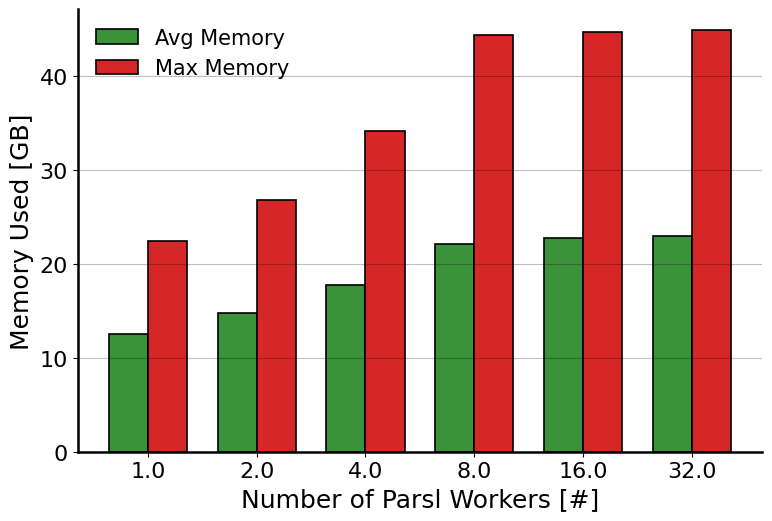

/tmp/ipykernel_125843/3151109461.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, axis="y", alpha=0.25, color="black")


[Saved] figures/cbr_workload_memory_usage.pdf


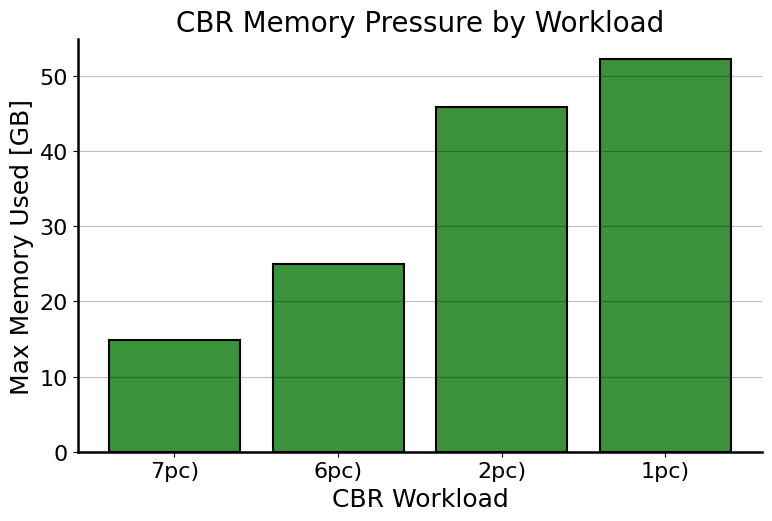

In [34]:
if not cbr_worker_col.empty:
    mem_df = summarize_by_workers(
        cbr_worker_col,
        ["avg_mem_used_gb", "max_mem_used_gb"]
    )
    display(mem_df)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    x = np.arange(len(mem_df))
    width = 0.36

    ax.bar(
        x - width/2,
        mem_df["avg_mem_used_gb"],
        width,
        label="Avg Memory",
        color=GREEN,
        edgecolor="black",
        linewidth=1.2
    )

    ax.bar(
        x + width/2,
        mem_df["max_mem_used_gb"],
        width,
        label="Max Memory",
        color=RED,
        edgecolor="black",
        linewidth=1.2
    )

    ax.set_xlabel("Number of Parsl Workers [#]")
    ax.set_ylabel("Memory Used [GB]")

    ax.set_xticks(x)
    ax.set_xticklabels(mem_df["workers"])

    ax.legend(frameon=False)

    clean_axes(ax, grid=False)
    plt.tight_layout()
    savefig("cbr_worker_memory_usage_bar.pdf")
    plt.show()

if not cbr_workload_col.empty:
    wl_mem = cbr_workload_col[cbr_workload_col["portion"].isin(portion_order)].copy()
    wl_mem["portion"] = pd.Categorical(wl_mem["portion"], categories=portion_order, ordered=True)
    wl_mem = wl_mem.sort_values("portion")
    wl_mem["label"] = wl_mem["portion"].astype(str) + ")"
    wl_mem["portion"].map(size_labels).astype(str) + ")"

    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.bar(wl_mem["label"], wl_mem["max_mem_used_gb"], color=GREEN, edgecolor="black", linewidth=1.5)
    ax.set_xlabel("CBR Workload")
    ax.set_ylabel("Max Memory Used [GB]")
    ax.set_title("CBR Memory Pressure by Workload")
    clean_axes(ax, grid=False)
    plt.tight_layout()
    savefig("cbr_workload_memory_usage.pdf")
    plt.show()


## Optional: Runtime and Resource Summary Tables


In [31]:
summary_tables = {}
if not ostrava_rt.empty:
    summary_tables["ostrava_worker_runtime"] = summarize_by_workers(ostrava_rt, ["conversion_sec", "wall_sec", "rss_gb"])
if not cbr_worker_rt.empty:
    summary_tables["cbr_worker_runtime"] = summarize_by_workers(cbr_worker_rt, ["conversion_sec", "wall_sec", "rss_gb", "cpu_percent"])
if not cbr_worker_col.empty:
    summary_tables["cbr_worker_collectl"] = summarize_by_workers(cbr_worker_col, ["avg_cpu_busy_pct", "max_cpu_busy_pct", "avg_mem_used_gb", "max_mem_used_gb"])

for name, df in summary_tables.items():
    out = FIG_DIR / f"{name}.csv"
    df.to_csv(out, index=False)
    print(f"[Saved] {out}")
    display(df)


[Saved] figures/ostrava_worker_runtime.csv


,workers,conversion_sec,wall_sec,rss_gb
0,1,113.270000,117.830000,2.817188
1,2,77.556667,82.353333,2.849286
2,4,56.653333,61.500000,2.859590
3,8,47.596667,52.493333,2.854031
4,16,50.403333,55.423333,2.870125
5,32,44.050000,48.370000,2.945999


[Saved] figures/cbr_worker_runtime.csv


,workers,conversion_sec,wall_sec,rss_gb,cpu_percent
0,1,753.34,800.51,22.902561,43.0
1,2,524.30,571.89,22.902576,59.0
2,4,415.94,463.33,22.901554,73.0
3,8,373.88,421.31,22.927593,82.0
4,16,377.75,425.05,22.928837,82.0
5,32,373.12,420.06,22.929218,82.0


[Saved] figures/cbr_worker_collectl.csv


,workers,avg_cpu_busy_pct,max_cpu_busy_pct,avg_mem_used_gb,max_mem_used_gb
0,1.0,7.488032,24.608641,12.565563,22.405571
1,2.0,10.734876,30.075188,14.761511,26.758053
2,4.0,13.912226,40.801001,17.726146,34.112125
3,8.0,16.538089,61.114590,22.138039,44.436604
4,16.0,16.671271,92.230576,22.735206,44.738285
5,32.0,16.798767,73.720350,22.954073,44.908092
